In [1]:
#%pip install matplotlib_scalebar

In [2]:
#%pip install pytables

In [1]:
#%pip install numpy==1.23.5

In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib_scalebar.scalebar import ScaleBar

from cellacdc import plot as acdc_plt
from cellacdc import load as acdc_load
#print(np.__version__)

# ***set path for image and spotmax output files*** 

In [2]:
images_path = r'C:\Users\yagya.chadha\Desktop\Yagya\FISH\2021-07-05 spotmax\1xprobe_4min\MMY\TIFFs\Position_19\Images'

smax_table_filepath = r"C:\Users\yagya.chadha\Desktop\Yagya\FISH\2021-07-05 spotmax\1xprobe_4min\MMY\TIFFs\Position_19\spotMAX_output\1_4_spotFIT_data_v1.h5"

df_smax = pd.read_hdf(smax_table_filepath)

#set channel names
channels = (
    'BF', 'DAPI', 'Q570'
)

# ***for each channel plot ROI and in fourth panel, plot spots and contours from spotmax*** 

array([[1698, 1700, 1698, ..., 1716, 1713, 1697],
       [1740, 1685, 1672, ..., 1651, 1674, 1692],
       [1729, 1692, 1708, ..., 1693, 1688, 1685],
       ...,
       [1721, 1679, 1702, ..., 1698, 1689, 1654],
       [1661, 1700, 1709, ..., 1675, 1713, 1666],
       [1706, 1691, 1716, ..., 1674, 1719, 1676]], dtype=uint16)

array([[276, 292, 271, ..., 297, 297, 284],
       [295, 270, 269, ..., 263, 273, 268],
       [281, 289, 267, ..., 274, 288, 277],
       ...,
       [285, 285, 266, ..., 269, 283, 298],
       [271, 264, 277, ..., 285, 301, 301],
       [288, 287, 281, ..., 285, 282, 307]], dtype=uint16)

array([[1129, 1098, 1092, ..., 1126, 1120, 1120],
       [1084, 1118, 1108, ..., 1095, 1098, 1087],
       [1098, 1125, 1123, ..., 1135, 1093, 1096],
       ...,
       [1088, 1119, 1152, ..., 1148, 1115, 1132],
       [1109, 1069, 1077, ..., 1146, 1154, 1171],
       [1105, 1125, 1130, ..., 1193, 1142, 1109]], dtype=uint16)

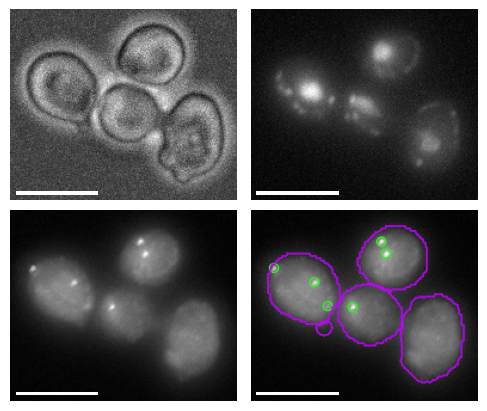

In [3]:
#ROI chosen from GUI
y0, x0 =  140, 220
Dy, Dx  =  160, 190

fig, a = plt.subplots(2, 2, figsize=(5, 4.5))
fig.subplots_adjust(
     left=0.03, right=0.97, top=0.97, bottom=0.1, 
    wspace=0.05, hspace=0.05
)
segm_data = acdc_load.load_segm_file(images_path)
segm_data = segm_data[y0:y0+Dy, x0:x0+Dx]

#crop max projection of each channels's image file, add scalebar and show in plot
for a, channel in enumerate(channels):
    img_filepath = acdc_load.get_filename_from_channel(images_path, channel)
    img_data = acdc_load.load_image_file(img_filepath)

    img_max_proj = img_data.max(axis=0)
    img_max_proj_crop = img_max_proj[y0:y0+Dy, x0:x0+Dx]
    display(img_max_proj_crop)

    fig.axes[a].imshow(img_max_proj_crop, cmap = 'gray')

    
    scalebar = ScaleBar(
        0.072, fixed_value =5, units='um', scale_loc = "none", width_fraction = 0.02, border_pad = 0.2, location='lower left', color='white', frameon=False
    )
    fig.axes[a].add_artist(scalebar)
    fig.axes[a].axis('off')
    if a == 3:
       fig.axes[-1].imshow(img_max_proj_crop) 

#add q570 image and cell contours to last panel
fig.axes[-1].imshow(img_max_proj_crop, cmap = 'gray')
acdc_plt.plt_contours(
    fig.axes[-1], lab=segm_data, 
    plot_kwargs={
        'color': '#be03fd', 
        'lw': 1.5, 
        'alpha': 0.8
    }
)

df_smax_crop = df_smax[(df_smax['x'] < x0+Dx) & (df_smax['y'] < y0+Dy)]

fig.axes[-1].axis('off')

#add spot markers to last panel
fig.axes[-1].scatter(
    df_smax_crop['x']-x0,
    df_smax_crop['y']-y0,
    facecolor='none', 
    edgecolor='#21fc0d', 
    s=42
)

#add scalebar to last panel
scalebar = ScaleBar(
        0.072, fixed_value =5, units='um', location='lower left', width_fraction = 0.02, border_pad = 0.2, scale_loc = "none", color='white', frameon=False
    )
fig.axes[-1].add_artist(scalebar)

#save figure 
#fig.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig1\FISH_exampleImages_SB5um.svg' ,bbox_inches='tight', dpi =150)
#fig.savefig(r'C:\Users\yagya.chadha\Desktop\Yagya\Presentations\Plots from Python\Final figures\Fig1\FISH_exampleImages_SB5um.png',  bbox_inches='tight', dpi =150)

plt.show()

In [ ]:
#image was inverted and colours of contours were changed in inkscape. 